# Unit12 Example 02 - 生產流程最大獲利之操作條件

本 Notebook 以**化學工廠生產流程線性規劃最適化**為例，示範如何建立線性目標函數、質量平衡等式限制與原料供應量邊界，並使用 `scipy.optimize.linprog()` 求解最大獲利之操作條件，最後進行敏感度分析。

## 目標
- 建立三原料三產品生產系統的線性規劃數學模型
- 正確設定目標函數係數、等式限制矩陣與變數邊界
- 使用 `linprog(method='highs')` 求解最大獲利（最大化轉最小化）
- 解讀最適化結果：各原料用量、各產品產量與每日最大獲利
- 進行敏感度分析：探討原料供應量變化與售價波動對最大獲利的影響

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit12_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit12'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit12
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_02\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import linprog

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
import matplotlib
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與數學模型

**問題背景：** 某化學工廠以三種原料（A、B、C）生產三種產品（E、F、G），原料供應量有限。試求每日最大獲利之操作條件。

**決策變數** $x_1 \sim x_6$ （lb/day）：

| 變數 | 說明 | 邊界 |
|------|------|------|
| $x_1$ | 原料 A 用量 | $0 \leq x_1 \leq 40000$ |
| $x_2$ | 原料 B 用量 | $0 \leq x_2 \leq 30000$ |
| $x_3$ | 原料 C 用量 | $0 \leq x_3 \leq 25000$ |
| $x_4$ | 產品 E 產量 | $x_4 \geq 0$ |
| $x_5$ | 產品 F 產量 | $x_5 \geq 0$ |
| $x_6$ | 產品 G 產量 | $x_6 \geq 0$ |

**目標函數（最大化每日獲利）：**

$$
\max F = 0.025x_4 + 0.028x_5 + 0.028x_6 - 0.015x_1 - 0.020x_2 - 0.025x_3
$$

**等式限制（質量平衡）：**

$$
x_1 - 0.667x_4 - 0.667x_5 - 0.500x_6 = 0
$$

$$
x_2 - 0.333x_4 - 0.333x_5 - 0.167x_6 = 0
$$

$$
x_3 - 0.333x_6 = 0
$$

In [3]:
# ============================================================
# 線性規劃問題參數設定
# ============================================================

# ── 變數名稱（方便輸出使用）────────────────────────────────
var_names = ['x1 (原料 A)', 'x2 (原料 B)', 'x3 (原料 C)',
             'x4 (產品 E)', 'x5 (產品 F)', 'x6 (產品 G)']

# ── 目標函數係數（最大化獲利 → 最小化負獲利）──────────────
# F_max = 0.025*x4 + 0.028*x5 + 0.028*x6 - 0.015*x1 - 0.020*x2 - 0.025*x3
# 最小化 c·x，其中 c = -獲利係數
c = np.array([0.015, 0.020, 0.025, -0.025, -0.028, -0.028])

print("目標函數係數向量 c（最小化方向）:")
for name, ci in zip(var_names, c):
    print(f"  {name}: {ci:+.3f}")

# ── 等式限制係數矩陣（質量平衡：Aeq·x = beq）─────────────
A_eq = np.array([
    [1.0,  0.0,  0.0, -0.667, -0.667, -0.500],   # 原料 A 平衡
    [0.0,  1.0,  0.0, -0.333, -0.333, -0.167],   # 原料 B 平衡
    [0.0,  0.0,  1.0,  0.000,  0.000, -0.333],   # 原料 C 平衡
])
b_eq = np.zeros(3)

print(f"\n等式限制矩陣 A_eq (shape={A_eq.shape}):")
print(A_eq)
print(f"等式限制右端向量 b_eq: {b_eq}")

# ── 變數邊界 [(lb, ub), ...]───────────────────────────────
bounds = [
    (0.0, 40000.0),  # x1: 原料 A，上限 40,000 lb/day
    (0.0, 30000.0),  # x2: 原料 B，上限 30,000 lb/day
    (0.0, 25000.0),  # x3: 原料 C，上限 25,000 lb/day
    (0.0, None),     # x4: 產品 E，無上限
    (0.0, None),     # x5: 產品 F，無上限
    (0.0, None),     # x6: 產品 G，無上限
]

print("\n變數邊界設定:")
for name, (lb, ub) in zip(var_names, bounds):
    ub_str = f"{ub:.0f}" if ub is not None else "+∞"
    print(f"  {name}: [{lb:.0f}, {ub_str}]")

目標函數係數向量 c（最小化方向）:
  x1 (原料 A): +0.015
  x2 (原料 B): +0.020
  x3 (原料 C): +0.025
  x4 (產品 E): -0.025
  x5 (產品 F): -0.028
  x6 (產品 G): -0.028

等式限制矩陣 A_eq (shape=(3, 6)):
[[ 1.     0.     0.    -0.667 -0.667 -0.5  ]
 [ 0.     1.     0.    -0.333 -0.333 -0.167]
 [ 0.     0.     1.     0.     0.    -0.333]]
等式限制右端向量 b_eq: [0. 0. 0.]

變數邊界設定:
  x1 (原料 A): [0, 40000]
  x2 (原料 B): [0, 30000]
  x3 (原料 C): [0, 25000]
  x4 (產品 E): [0, +∞]
  x5 (產品 F): [0, +∞]
  x6 (產品 G): [0, +∞]


---
### 3. 求解線性規劃問題

In [4]:
# ============================================================
# 使用 scipy.optimize.linprog 求解
# ============================================================
result = linprog(
    c,
    A_ub=None,
    b_ub=None,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method='highs'
)

# ── 求解結果輸出 ─────────────────────────────────────────────
print("=" * 52)
print("  linprog (HiGHS) 求解結果")
print("=" * 52)
print(f"  收斂狀態  : {'成功 ✓' if result.success else '失敗 ✗'}")
print(f"  求解器訊息: {result.message}")
print(f"  迭代次數  : {result.nit}")
print(f"  目標函數值（-獲利）: {result.fun:.3f}")
print("=" * 52)

x_opt = result.x
max_profit = -result.fun   # 最大化獲利 = -min(-F)

supply_upper = [40000, 30000, 25000, None, None, None]

print("\n  決策變數最佳解：")
for name, xi, bounds_i in zip(var_names, x_opt, bounds):
    if bounds_i[1] is not None:
        status = "已達上限" if abs(xi - bounds_i[1]) < 1e-3 else f"上限 {bounds_i[1]:.0f}"
        print(f"    {name} = {xi:10.3f} lb/day  [{status}]")
    else:
        print(f"    {name} = {xi:10.3f} lb/day")

print(f"\n  每日最大獲利 F* = {max_profit:.3f} $/day")
print("=" * 52)

  linprog (HiGHS) 求解結果
  收斂狀態  : 成功 ✓
  求解器訊息: Optimization terminated successfully. (HiGHS Status 7: Optimal)
  迭代次數  : 2
  目標函數值（-獲利）: -705.135

  決策變數最佳解：
    x1 (原料 A) =  40000.000 lb/day  [已達上限]
    x2 (原料 B) =  13766.923 lb/day  [上限 30000]
    x3 (原料 C) =  25000.000 lb/day  [已達上限]
    x4 (產品 E) =      0.000 lb/day
    x5 (產品 F) =   3691.848 lb/day
    x6 (產品 G) =  75075.075 lb/day

  每日最大獲利 F* = 705.135 $/day


In [5]:
# ============================================================
# 限制條件驗證與財務分解
# ============================================================

# ── 等式限制殘差驗證 ─────────────────────────────────────────
residuals = A_eq @ x_opt - b_eq
tol = 1e-6
print("質量平衡殘差驗證（|Aeq·x - beq| ≤ tol）：")
eq_labels = ['原料 A 平衡', '原料 B 平衡', '原料 C 平衡']
for label, res in zip(eq_labels, residuals):
    status = "✓" if abs(res) <= tol else "✗"
    print(f"  {label}: residual = {res:.2e}  {status}")

# ── 財務分解 ─────────────────────────────────────────────────
price_E, price_F, price_G = 0.040, 0.033, 0.038
cost_A,  cost_B,  cost_C  = 0.015, 0.020, 0.025
opex_E,  opex_F,  opex_G  = 0.015, 0.005, 0.010

revenue    = price_E * x_opt[3] + price_F * x_opt[4] + price_G * x_opt[5]
raw_cost   = cost_A  * x_opt[0] + cost_B  * x_opt[1] + cost_C  * x_opt[2]
oper_cost  = opex_E  * x_opt[3] + opex_F  * x_opt[4] + opex_G  * x_opt[5]
net_profit = revenue - raw_cost - oper_cost

print(f"\n財務分解：")
print(f"  銷售收入      : {revenue:>10.3f} $/day")
print(f"  原料成本      : {raw_cost:>10.3f} $/day  ({raw_cost/revenue*100:.1f}% of revenue)")
print(f"  操作成本      : {oper_cost:>10.3f} $/day  ({oper_cost/revenue*100:.1f}% of revenue)")
print(f"  ─────────────────────────────────")
print(f"  淨獲利（驗算）: {net_profit:>10.3f} $/day")

質量平衡殘差驗證（|Aeq·x - beq| ≤ tol）：
  原料 A 平衡: residual = 0.00e+00  ✓
  原料 B 平衡: residual = 0.00e+00  ✓
  原料 C 平衡: residual = 0.00e+00  ✓

財務分解：
  銷售收入      :   2974.684 $/day
  原料成本      :   1500.338 $/day  (50.4% of revenue)
  操作成本      :    769.210 $/day  (25.9% of revenue)
  ─────────────────────────────────
  淨獲利（驗算）:    705.135 $/day


---
### 4. 最適解視覺化

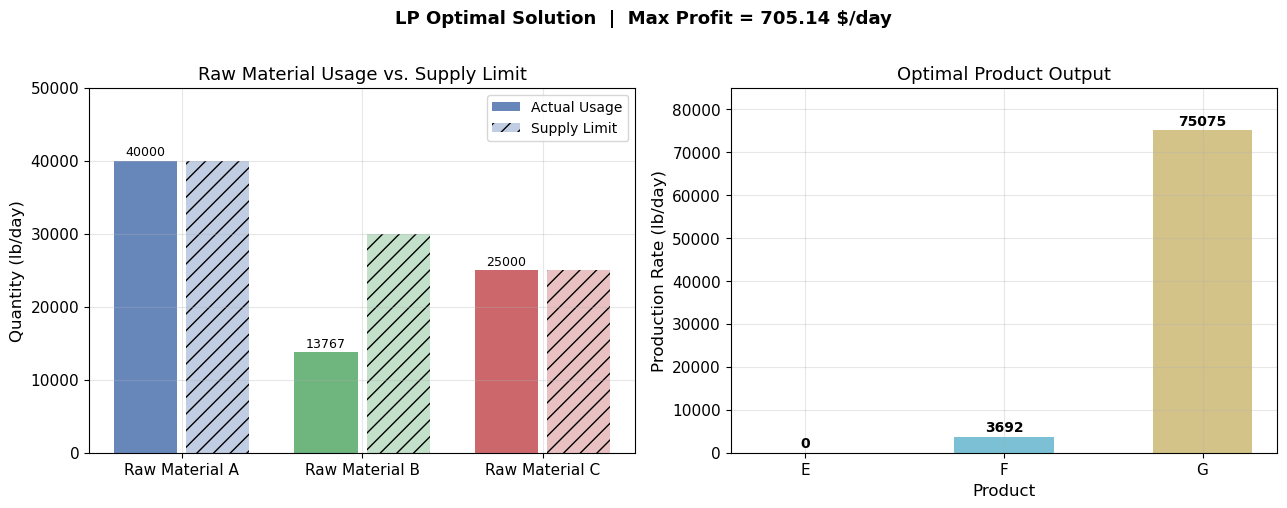

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_02\figs\fig_01_optimal_allocation.png


In [6]:
# ============================================================
# 圖1: 最適解資源分配雙軸圖
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 左子圖：原料用量 vs 供應上限 ────────────────────────────
ax1 = axes[0]
raw_labels  = ['A', 'B', 'C']
raw_used    = x_opt[:3]
raw_limits  = [40000, 30000, 25000]
colors_raw  = ['#4C72B0', '#55A868', '#C44E52']

x_pos = np.arange(len(raw_labels))
bars1 = ax1.bar(x_pos - 0.2, raw_used,   width=0.35, label='Actual Usage',  color=colors_raw, alpha=0.85)
bars2 = ax1.bar(x_pos + 0.2, raw_limits, width=0.35, label='Supply Limit', color=colors_raw, alpha=0.35, hatch='//')

# 標示數值
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(['Raw Material A', 'Raw Material B', 'Raw Material C'])
ax1.set_ylabel('Quantity (lb/day)')
ax1.set_title('Raw Material Usage vs. Supply Limit')
ax1.legend()
ax1.set_ylim(0, 50000)

# ── 右子圖：產品產量 ──────────────────────────────────────────
ax2 = axes[1]
prod_labels = ['E', 'F', 'G']
prod_vals   = x_opt[3:]
colors_prod = ['#8172B2', '#64B5CD', '#CCB974']

bars3 = ax2.bar(prod_labels, prod_vals, color=colors_prod, alpha=0.85, width=0.5)
for bar, val in zip(bars3, prod_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Production Rate (lb/day)')
ax2.set_title('Optimal Product Output')
ax2.set_ylim(0, 85000)
ax2.set_xlabel('Product')

fig.suptitle(f'LP Optimal Solution  |  Max Profit = {max_profit:.2f} $/day',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
fpath = FIG_DIR / 'fig_01_optimal_allocation.png'
plt.savefig(fpath, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fpath}")

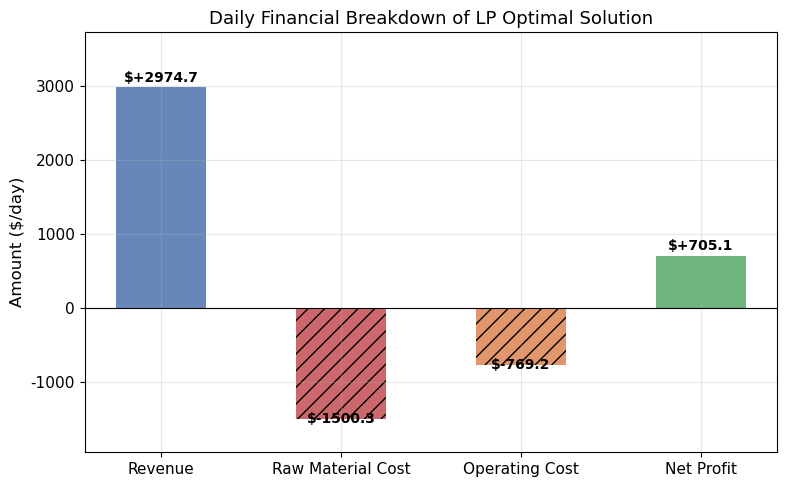

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_02\figs\fig_02_profit_breakdown.png


In [7]:
# ============================================================
# 圖2: 每日獲利成本分解圖
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

categories    = ['Revenue', 'Raw Material Cost', 'Operating Cost', 'Net Profit']
values        = [revenue, -raw_cost, -oper_cost, net_profit]
bar_colors    = ['#4C72B0', '#C44E52', '#DD8452', '#55A868']
bar_hatches   = ['', '//', '//', '']

bars = ax.bar(categories, values, color=bar_colors, alpha=0.85, width=0.5)
for bar, h in zip(bars, bar_hatches):
    bar.set_hatch(h)

# 標示數值
for bar, val in zip(bars, values):
    ypos = bar.get_height() + 30 if val >= 0 else bar.get_height() - 100
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'${val:+.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Amount ($/day)')
ax.set_title('Daily Financial Breakdown of LP Optimal Solution')
ax.set_ylim(min(values) * 1.3, max(values) * 1.25)

plt.tight_layout()
fpath = FIG_DIR / 'fig_02_profit_breakdown.png'
plt.savefig(fpath, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fpath}")

---
### 5. 敏感度分析 — 原料供應量變動

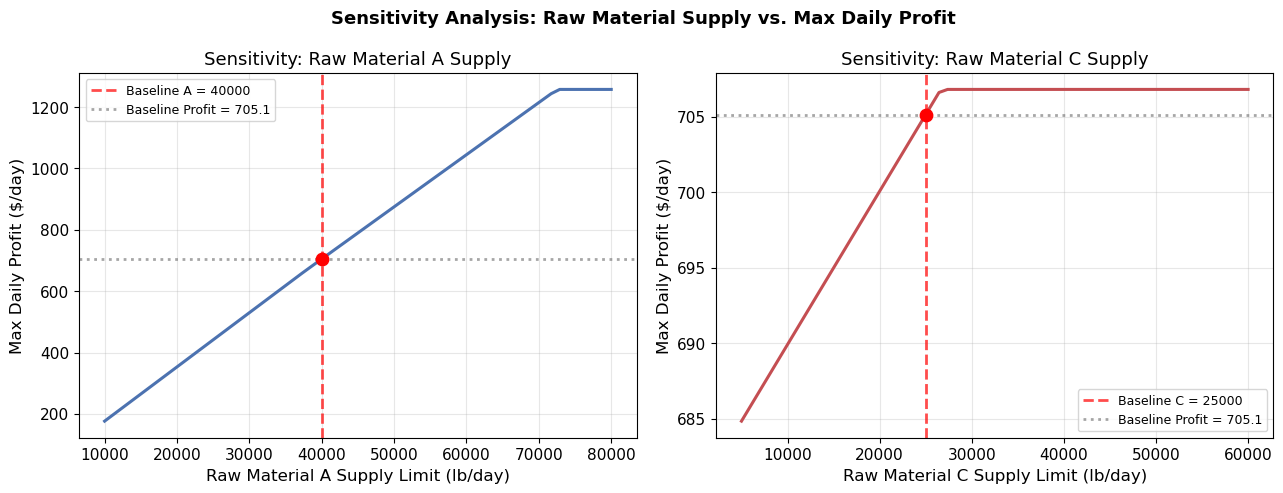

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_02\figs\fig_03_sensitivity_supply.png

  影子價格估算（於基準點）：
  原料 A: 0.01699 $/(lb/day)
  原料 C: 0.00102 $/(lb/day)


In [8]:
# ============================================================
# 敏感度分析：原料 A、C 供應量上限變動對最大獲利的影響
# ============================================================

def solve_lp(A_upper=40000, B_upper=30000, C_upper=25000,
             price_e=0.040, price_f=0.033, price_g=0.038):
    """通用 LP 求解函式，回傳最大獲利（失敗時回傳 NaN）"""
    c_vec = np.array([0.015, 0.020, 0.025, -price_e + 0.015, -price_f + 0.005, -price_g + 0.010])
    bds  = [(0, A_upper), (0, B_upper), (0, C_upper), (0, None), (0, None), (0, None)]
    res  = linprog(c_vec, A_eq=A_eq, b_eq=b_eq, bounds=bds, method='highs')
    return -res.fun if res.success else np.nan

# 掃描範圍：原料 A（10000 ~ 80000）、原料 C（5000 ~ 60000）
A_range = np.linspace(10000, 80000, 60)
C_range = np.linspace(5000,  60000, 60)

profit_vs_A = [solve_lp(A_upper=a) for a in A_range]
profit_vs_C = [solve_lp(C_upper=c) for c in C_range]

# ── 繪圖 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左: 原料 A 供應量
axes[0].plot(A_range, profit_vs_A, color='#4C72B0', linewidth=2.2)
axes[0].axvline(40000, color='red', linestyle='--', alpha=0.7, label='Baseline A = 40000')
axes[0].axhline(max_profit, color='gray', linestyle=':', alpha=0.7, label=f'Baseline Profit = {max_profit:.1f}')
axes[0].scatter([40000], [max_profit], color='red', zorder=5, s=80)
axes[0].set_xlabel('Raw Material A Supply Limit (lb/day)')
axes[0].set_ylabel('Max Daily Profit ($/day)')
axes[0].set_title('Sensitivity: Raw Material A Supply')
axes[0].legend(fontsize=9)

# 右: 原料 C 供應量
axes[1].plot(C_range, profit_vs_C, color='#C44E52', linewidth=2.2)
axes[1].axvline(25000, color='red', linestyle='--', alpha=0.7, label='Baseline C = 25000')
axes[1].axhline(max_profit, color='gray', linestyle=':', alpha=0.7, label=f'Baseline Profit = {max_profit:.1f}')
axes[1].scatter([25000], [max_profit], color='red', zorder=5, s=80)
axes[1].set_xlabel('Raw Material C Supply Limit (lb/day)')
axes[1].set_ylabel('Max Daily Profit ($/day)')
axes[1].set_title('Sensitivity: Raw Material C Supply')
axes[1].legend(fontsize=9)

fig.suptitle('Sensitivity Analysis: Raw Material Supply vs. Max Daily Profit',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fpath = FIG_DIR / 'fig_03_sensitivity_supply.png'
plt.savefig(fpath, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fpath}")

# ── 影子價格估算 ─────────────────────────────────────────────
dA = A_range[1] - A_range[0]
shadow_A = np.gradient(profit_vs_A, dA)[np.argmin(abs(A_range - 40000))]
dC = C_range[1] - C_range[0]
shadow_C = np.gradient(profit_vs_C, dC)[np.argmin(abs(C_range - 25000))]
print(f"\n  影子價格估算（於基準點）：")
print(f"  原料 A: {shadow_A:.5f} $/(lb/day)")
print(f"  原料 C: {shadow_C:.5f} $/(lb/day)")

---
### 6. 敏感度分析 — 產品售價波動

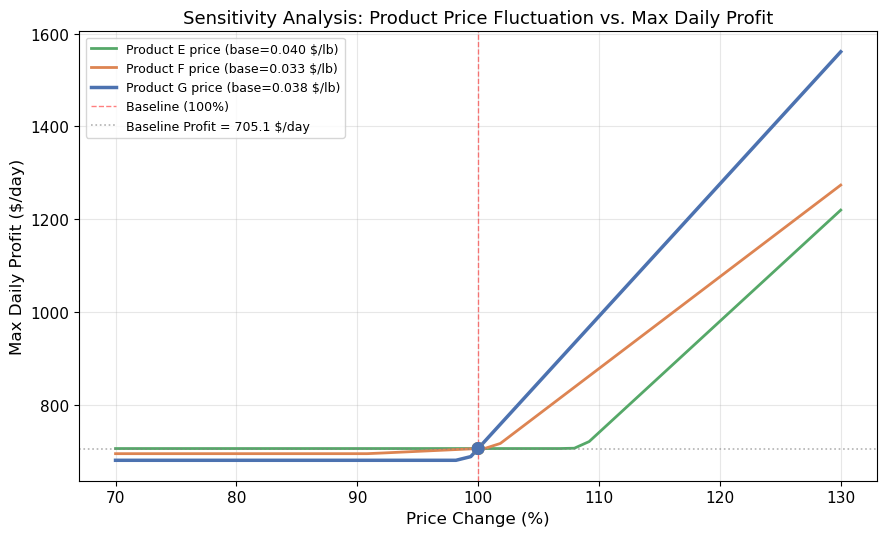

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_02\figs\fig_04_sensitivity_price.png


In [9]:
# ============================================================
# 敏感度分析：各產品售價波動對最大獲利的影響
# ============================================================

# 基準售價
p_E_base, p_F_base, p_G_base = 0.040, 0.033, 0.038

# 掃描範圍：基準值 ± 30%
pct_range = np.linspace(0.7, 1.3, 50)

profit_price_E = [solve_lp(price_e=p_E_base * p) for p in pct_range]
profit_price_F = [solve_lp(price_f=p_F_base * p) for p in pct_range]
profit_price_G = [solve_lp(price_g=p_G_base * p) for p in pct_range]

# ── 繪圖 ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(pct_range * 100, profit_price_E, color='#55A868', linewidth=2,   label=f'Product E price (base={p_E_base:.3f} $/lb)')
ax.plot(pct_range * 100, profit_price_F, color='#DD8452', linewidth=2,   label=f'Product F price (base={p_F_base:.3f} $/lb)')
ax.plot(pct_range * 100, profit_price_G, color='#4C72B0', linewidth=2.5, label=f'Product G price (base={p_G_base:.3f} $/lb)')

ax.axvline(100, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Baseline (100%)')
ax.axhline(max_profit, color='gray', linestyle=':', alpha=0.6, linewidth=1.2,
           label=f'Baseline Profit = {max_profit:.1f} $/day')
ax.scatter([100, 100, 100], [max_profit]*3, color=['#55A868','#DD8452','#4C72B0'], s=70, zorder=5)

ax.set_xlabel('Price Change (%)')
ax.set_ylabel('Max Daily Profit ($/day)')
ax.set_title('Sensitivity Analysis: Product Price Fluctuation vs. Max Daily Profit')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
fpath = FIG_DIR / 'fig_04_sensitivity_price.png'
plt.savefig(fpath, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存: {fpath}")

---
### 7. 重點整理

- **每日最大獲利 $F^* = 705.135$ \$/day**，最佳操作策略：
  - 原料 A：耗盡（40,000 lb/day），原料 C：耗盡（25,000 lb/day），原料 B 剩餘（13,767 lb/day）
  - 不生產產品 E（ $x_4 = 0$ ），主力生產產品 G（75,075 lb/day），少量生產 F（3,692 lb/day）
- `scipy.optimize.linprog()` 的 **`method='highs'`** 採用 HiGHS 求解器，效率高、數值穩定
- 最大化問題透過**目標係數取負號**轉為最小化： $\max F = -\min(-F)$
- **等式限制**對應化工質量平衡方程式，格式為 $\mathbf{A}_{eq}\mathbf{x} = \mathbf{b}_{eq}$
- 綁定限制（binding constraint）的**影子價格**反映採購決策的邊際效益
- 敏感度分析揭示原料 A、C 的供應量與 G 的售價對獲利最具影響力